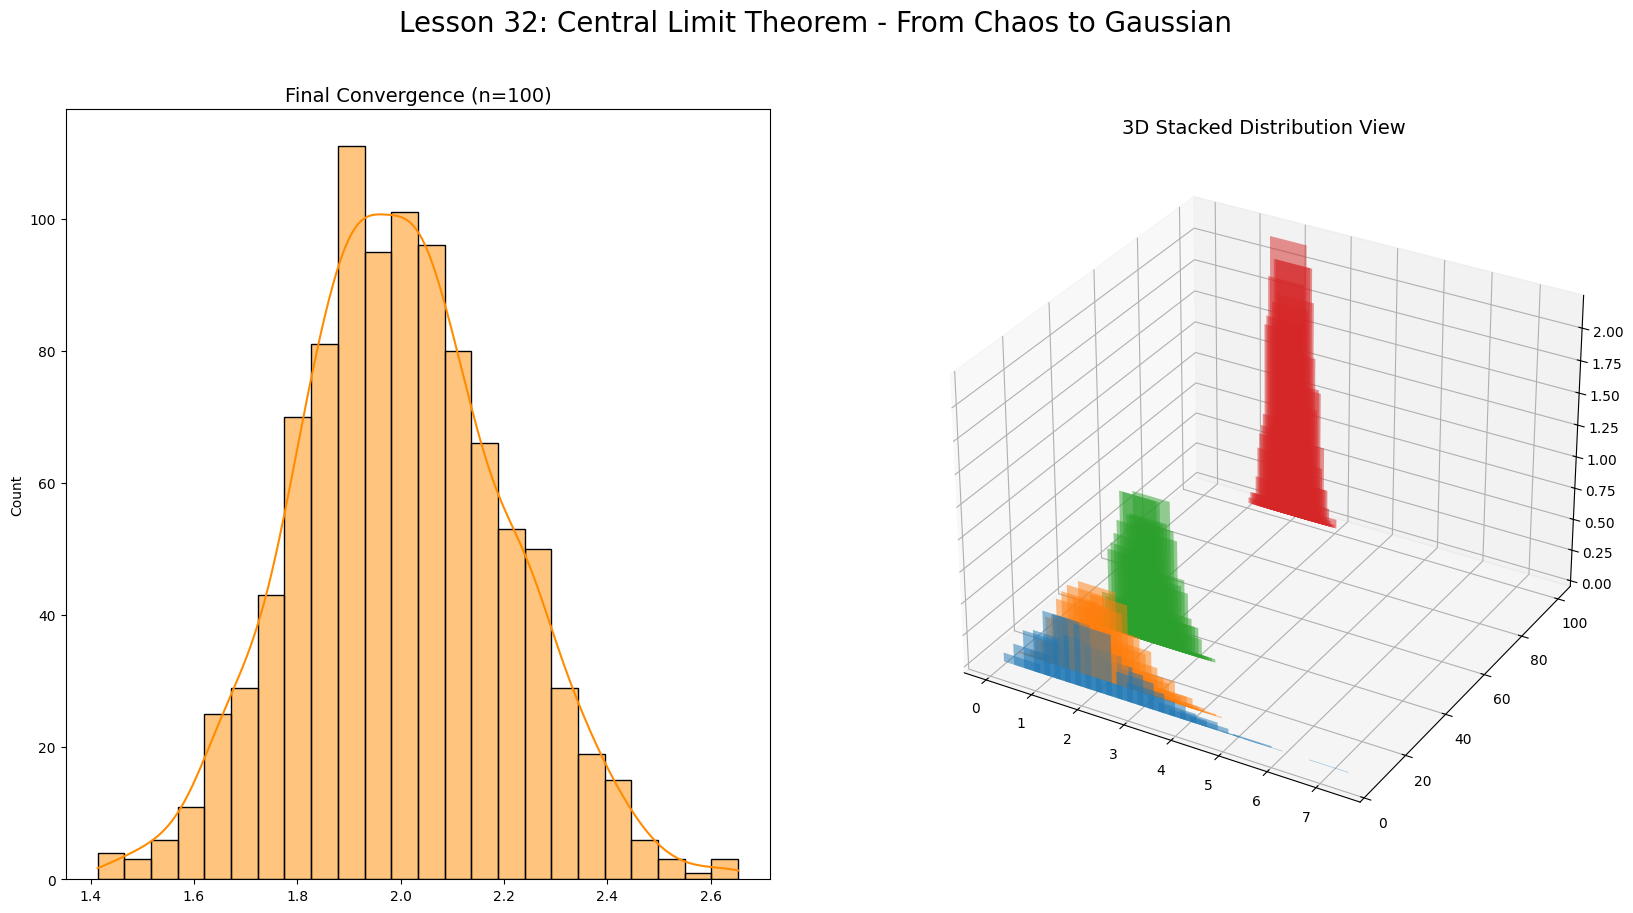

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import os

def run_clt_simulation():
    # Assets yolu
    asset_path = '../../../assets'
    if not os.path.exists(asset_path): os.makedirs(asset_path)

    # 1. Orijinal Dağılım (Hiç alakası olmayan Üstel/Exponential Dağılım)
    np.random.seed(7)
    population = np.random.exponential(scale=2, size=10000)

    # 2. Örneklem Ortalamalarını Hesaplama
    sample_sizes = [5, 10, 30, 100]
    sample_means_list = []
    for n in sample_sizes:
        means = [np.mean(np.random.choice(population, n)) for _ in range(1000)]
        sample_means_list.append(means)

    # --- ASSET 1: 2D VISUALIZATION (Step-by-Step Convergence) ---
    fig2d, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    for i, n in enumerate(sample_sizes):
        sns.histplot(sample_means_list[i], kde=True, ax=axes[i], color='darkorange')
        axes[i].set_title(f'Sample Size n={n}')
    
    plt.suptitle("2D CLT: Transformation of Exponential Means to Normal Distribution", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f'{asset_path}/32_clt_2d.png', dpi=300)
    plt.close(fig2d)

    # --- ASSET 2: 3D VISUALIZATION (Stacked Histograms) ---
    fig3d = plt.figure(figsize=(12, 8))
    ax3d = fig3d.add_subplot(111, projection='3d')
    
    colors = ['r', 'g', 'b', 'm']
    for i, n in enumerate(sample_sizes):
        hist, bins = np.histogram(sample_means_list[i], bins=30, density=True)
        xs = (bins[:-1] + bins[1:]) / 2
        ax3d.bar(xs, hist, zs=n, zdir='y', color=colors[i], alpha=0.6, width=0.2)

    ax3d.set_title("3D CLT Evolution: Distribution Narrowing with Sample Size")
    ax3d.set_xlabel('Sample Mean')
    ax3d.set_ylabel('Sample Size (n)')
    ax3d.set_zlabel('Density')
    
    plt.savefig(f'{asset_path}/32_clt_3d.png', dpi=300)
    plt.close(fig3d)

    # --- MASTER DASHBOARD ---
    master_fig = plt.figure(figsize=(20, 10))
    
    # Left Side: 2D Multi-plot
    ax_left = master_fig.add_subplot(121)
    sns.histplot(sample_means_list[-1], kde=True, ax=ax_left, color='darkorange')
    ax_left.set_title(f"Final Convergence (n={sample_sizes[-1]})", fontsize=14)

    # Right Side: 3D Perspective
    ax_right = master_fig.add_subplot(122, projection='3d')
    for i, n in enumerate(sample_sizes):
        hist, bins = np.histogram(sample_means_list[i], bins=30, density=True)
        xs = (bins[:-1] + bins[1:]) / 2
        ax_right.bar(xs, hist, zs=n, zdir='y', alpha=0.5)
    ax_right.set_title("3D Stacked Distribution View", fontsize=14)

    plt.suptitle("Lesson 32: Central Limit Theorem - From Chaos to Gaussian", fontsize=20)
    plt.show()

if __name__ == "__main__":
    run_clt_simulation()